# Практика по Conv2D

In [5]:
! pip install tensorflow
import tensorflow as tf
import numpy as np
#tf.enable_eager_execution()
from tensorflow.keras.layers import Conv2D
from skimage import data
import matplotlib.pyplot as plt

(1, 512, 512, 1)


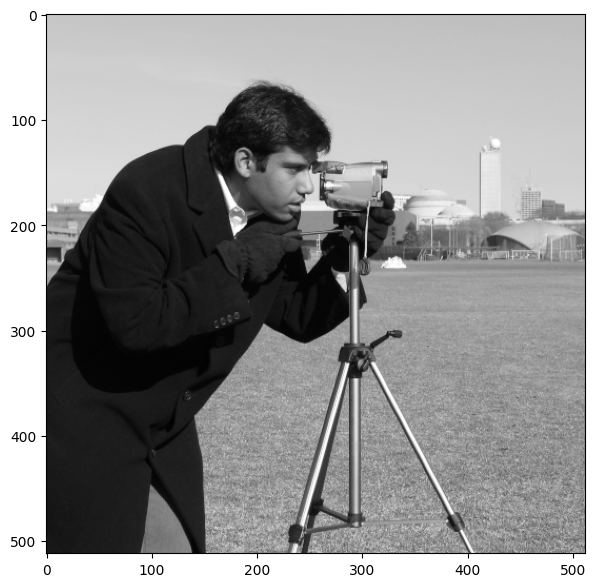

In [ ]:
image = data.camera()
plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")
image = image[None, ..., None].astype(np.float32) / 255.
print(image.shape)

## Практическое задание 1

Реализуйте фильтр для детектирования вертикальных линий. Размер изображения не должен измениться.

Shape после подготовки: (1, 512, 512, 1)
Размер ядра: (3, 3, 1, 1)
Input shape (1, 512, 512, 1). Output shape (1, 512, 512, 1)
Tests passed


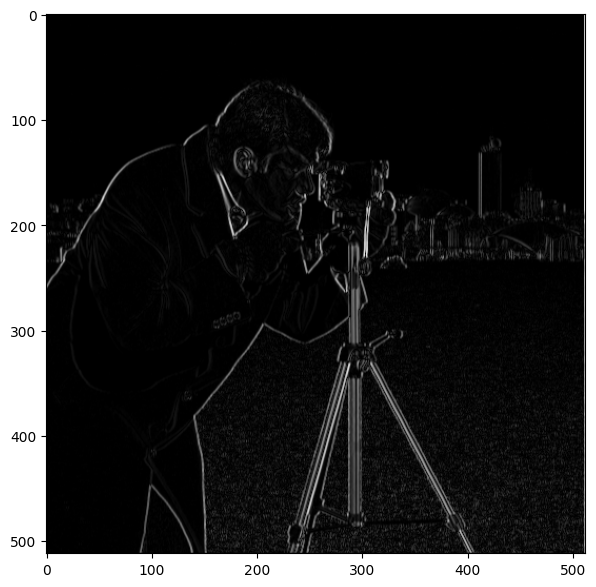

In [ ]:
# < YOUR CODE STARTS HERE >
# 1. определите слой conv_layer так чтобы размер выходного изображения не изменился
# 2. примените его к image для инициализации
# 3. определите kernel = [[1, 0, -1], [2, 0, -2], [1, 0, -1]] .
# 4. не забудьте задать ему правильный размер
# 5. conv_layer.set_weights([kernel])
# После этого вы получите изображение с задетектированными линиями

print(f"Shape после подготовки: {image.shape}")
conv_layer = Conv2D(kernel_size=(3, 3), filters=1, use_bias=False, padding='same')
_ = conv_layer(image) # чтобы получить доступ к весам слоя нужно один раз им воспользоваться
#cоздаем ядро
kernel = np.array([
    [[[1]], [[0]], [[-1]]],
    [[[2]], [[0]], [[-2]]],
    [[[1]], [[0]], [[-1]]]
], dtype=np.float32)
print(f"Размер ядра: {kernel.shape}")

#устанавливаем веса
conv_layer.set_weights([kernel])
#применяем свертку
detected_lines = conv_layer(image)




#визуализация
plt.figure(figsize=(7, 7))
plt.imshow(np.abs(detected_lines.numpy()[0, :,:, 0]), cmap="gray")
print(f"Input shape {image.shape}. Output shape {conv_layer(image).numpy().shape}")
assert image.shape  == detected_lines.shape
print("Tests passed")

## Практическое задание 2

Реализуйте свертку, которая повысит резкость цветного изображения и не изменит его размер.

Это делается с помощью такого фильтра:



```
[[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]]
```



(1, 400, 600, 3)


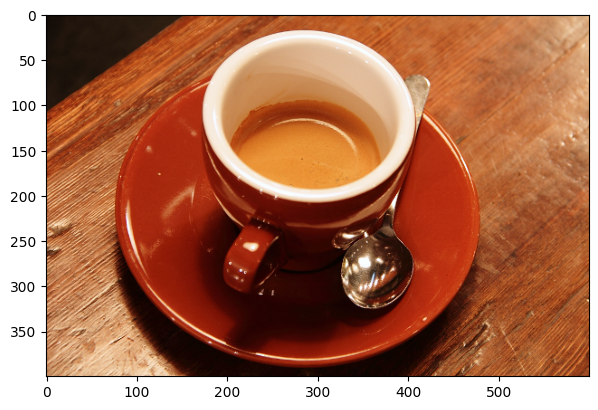

In [9]:
image = data.coffee()
plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")
image = image[None, ...].astype(np.float32) / 255.
print(image.shape)

Shape после подготовки: (1, 400, 600, 3)
Размер ядра: (3, 3, 3, 3)
Ядро[0, 0, :, :]: [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Input shape (1, 400, 600, 3). Output shape (1, 400, 600, 3)
Tests passed


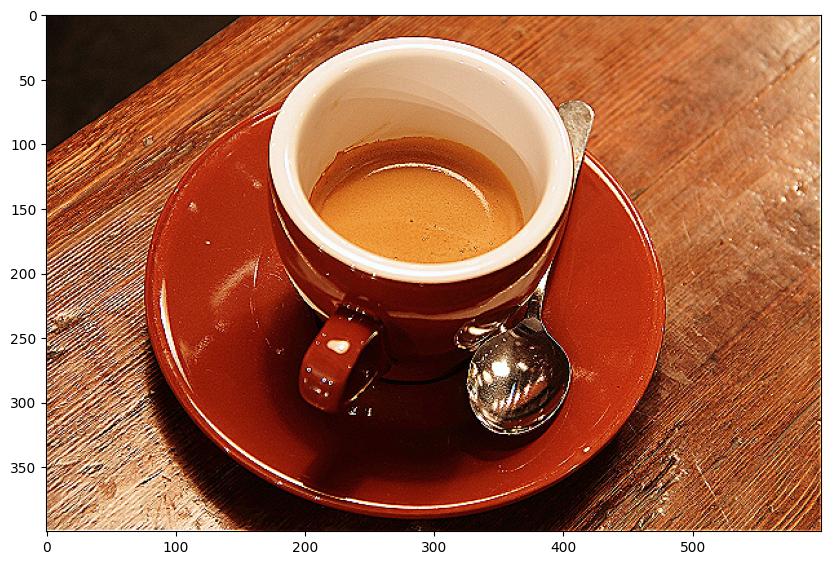

In [10]:
# < YOUR CODE STARTS HERE >
# 1. определите слой conv_layer так чтобы размер выходного изображения не изменился
# 2. примените его к image для инициализации
# 3. определите sharpen_kernel_2d= [[0, -1, 0],
#                                   [-1, 5, -1],
#                                   [0, -1, 0]]
# 4. По аналогии с размытием  цветного изображения сделайте так, чтобы этот фильтр
#    применился к каждом каналу независимо определив переменную kernel размера (3,3,3,3). Там должно быть много нулей
# 5. conv_layer.set_weights([kernel])
# После этого вы получите изображение повышенной резкостью
print(f"Shape после подготовки: {image.shape}")
conv_layer = Conv2D(kernel_size=(3, 3), filters=3, use_bias=False, padding='same')
_ = conv_layer(image) # чтобы получить доступ к весам слоя нужно один раз им воспользоваться
#создаем базовое ядро для одного канала
sharpen_kernel_2d = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)


#создаем диагональную матрицу 3 на 3
kernel = np.zeros((3, 3, 3, 3), dtype=np.float32)
#заполняем: каждый выходной канал получает данные только из своего входного канала
for i in range(3):
    kernel[:, :, i, i] = sharpen_kernel_2d


print(f"Размер ядра: {kernel.shape}")
#диагональная матрица
print(f"Ядро[0, 0, :, :]: {kernel[0, 0, :, :]}")

#устанавливаем веса
conv_layer.set_weights([kernel])
#применяем свертку





# < YOUR CODE ENDS HERE >
sharpen_image = conv_layer(image).numpy()
plt.figure(figsize=(10, 10))
plt.imshow(sharpen_image[0])
print(f"Input shape {image.shape}. Output shape {sharpen_image.shape}")
assert image.shape  == sharpen_image.shape
print("Tests passed")

In [11]:
#загружаем изображение
image = data.camera()
image = image[None, ..., None].astype(np.float32) / 255.
print(f"Input shape: {image.shape}")  # (1, 512, 512, 1)

Input shape: (1, 512, 512, 1)


In [12]:
#создаем слой с 32 фильтрами
conv_layer_32 = Conv2D(kernel_size=(3, 3), filters=32, use_bias=False, padding='same')
#инициализируем
_ = conv_layer_32(image)

In [13]:
#создаем разные ядра для каждого фильтра
kernels_32 = []
#базовые ядра для разных типов детекции
sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
edge_h = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)  # горизонтальные
edge_v = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float32)   # вертикальные
blur = np.array([[1/9, 1/9, 1/9], [1/9, 1/9, 1/9], [1/9, 1/9, 1/9]], dtype=np.float32)
emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]], dtype=np.float32)
#создаем 32 разных фильтра
for i in range(32):
    # Чередуем разные типы ядер
    if i % 5 == 0:
        kernel_type = sharpen
    elif i % 5 == 1:
        kernel_type = edge_h
    elif i % 5 == 2:
        kernel_type = edge_v
    elif i % 5 == 3:
        kernel_type = blur
    else:
        kernel_type = emboss

    #добавляем небольшие случайные вариации
    variation = np.random.normal(0, 0.1, (3, 3))
    kernel = kernel_type + variation

    #формируем ядро (3, 3, 1, 1) для grayscale
    kernel_3d = np.zeros((3, 3, 1, 1), dtype=np.float32)
    kernel_3d[:, :, 0, 0] = kernel
    kernels_32.append(kernel_3d)

In [14]:
#объединяем все ядра в один массив (3, 3, 1, 32)
all_kernels = np.concatenate(kernels_32, axis=-1)  # axis=-1 объединяет по выходным каналам
print(f"Размер всех ядер: {all_kernels.shape}")  # (3, 3, 1, 32)

Размер всех ядер: (3, 3, 1, 32)


Output shape: (1, 512, 512, 32)


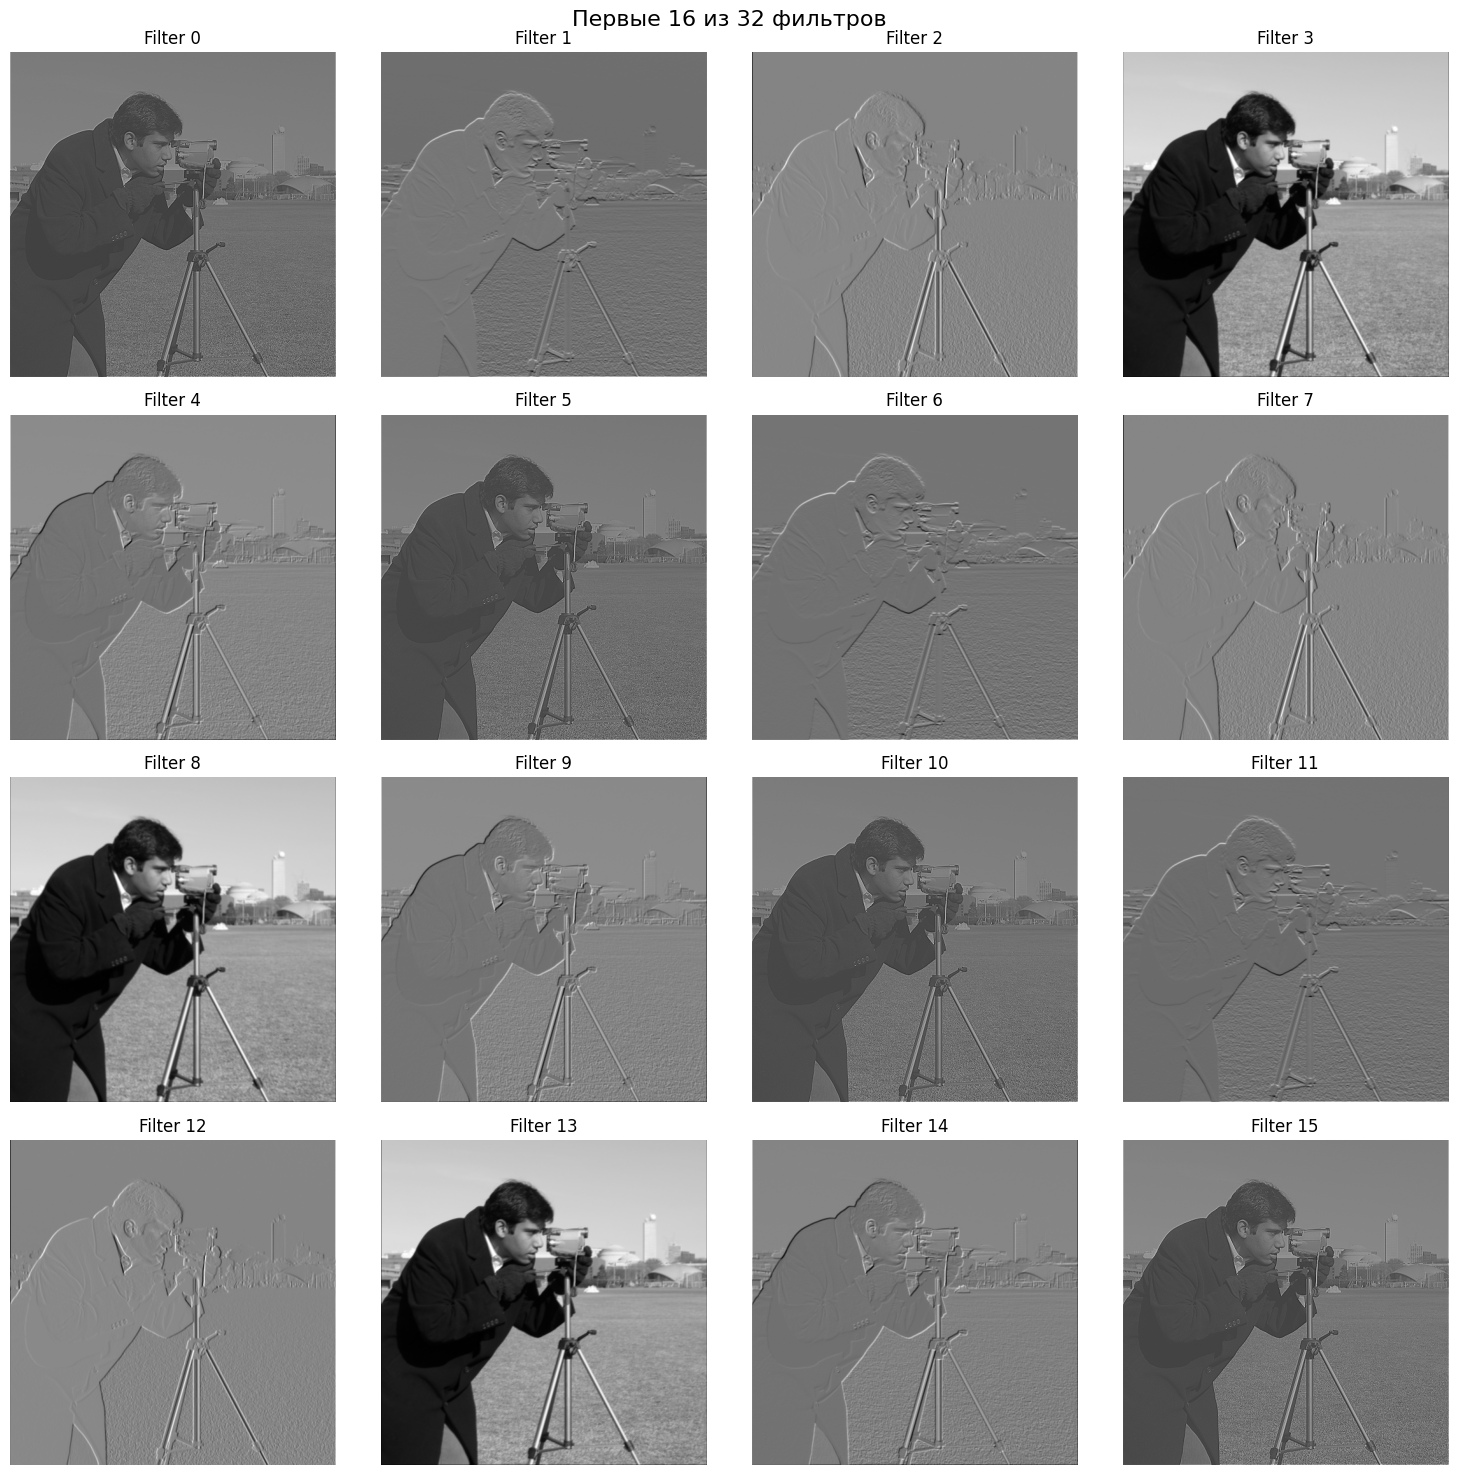

In [15]:
#устанавливаем веса
conv_layer_32.set_weights([all_kernels])
#применяем свертку
output_32 = conv_layer_32(image).numpy()
print(f"Output shape: {output_32.shape}")  # (1, 512, 512, 32) - 32 карты признаков!
#визуализируем первые 16 фильтров
plt.figure(figsize=(15, 15))
for i in range(16):  # покажем первые 16 из 32
    plt.subplot(4, 4, i+1)

    # Берем i-ю карту признаков
    feature_map = output_32[0, :, :, i]

    # Нормализуем для отображения
    feature_map_norm = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min() + 1e-8)

    plt.imshow(feature_map_norm, cmap='gray')
    plt.title(f'Filter {i}')
    plt.axis('off')

plt.suptitle('Первые 16 из 32 фильтров', fontsize=16)
plt.tight_layout()
plt.show()